In [28]:
import os
import sys

sys.path.append(os.path.abspath(".."))

import pandas as pd
import pgeocode
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from src.data_loader import load_data

In [29]:
transactions_data = load_data("../data/processed/transactions_train.csv", online_trx=False, users_path="../data/raw/users_data.csv", cards_path="../data/raw/cards_data.csv", undersampling=True)

In [30]:
cards_data = pd.read_csv("../data/raw/cards_data.csv")
cards_data.rename(columns={"id":"card_id"}, inplace=True)

In [31]:
users_data = pd.read_csv("../data/raw/users_data.csv")
users_data.rename(columns={"id":"client_id"}, inplace=True)


In [32]:
print("Transactions data before: ", transactions_data.shape)
df = transactions_data.merge(users_data, on="client_id",)
print("Transactions data after: ", df.shape)


Transactions data before:  (164900, 25)
Transactions data after:  (164900, 38)


In [33]:
print("Transactions data before: ", df.shape)
df = df.merge(cards_data, on="card_id",)
print("Transactions data after: ", df.shape)

Transactions data before:  (164900, 38)
Transactions data after:  (164900, 50)


In [34]:
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.day_of_week

In [35]:
transactions_data.describe()

,date,id,client_id,card_id,amount,merchant_id,zip,mcc,prev_fraud_count,online_history_ratio,trx_count_1h,trx_amount_1h,has_bad_cvv,has_bad_pin,has_insufficient_balance,has_technical_glitch,insufficient_balance_count_1h,bad_cvv_count_1h,bad_pin_count_1h,tech_glitch_count_1h
count,164900,1.649000e+05,164900.000000,164900.000000,164900.000000,164900.00000,163250.000000,164900.000000,164900.000000,164900.000000,164900.000000,164900.000000,164900.0,164900.0,164900.0,164900.0,164900.0,164900.0,164900.0,164900.0
mean,2014-01-30 11:37:08.443662592,1.400673e+07,1021.059521,3465.667641,41.316052,48680.55997,51259.171430,5645.510746,1.648999,0.094323,0.195925,5.601947,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,2010-01-01 00:01:00,7.475327e+06,0.000000,0.000000,-500.000000,5.00000,1001.000000,1711.000000,0.000000,0.000000,0.000000,-807.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2012-02-09 05:30:30,1.070833e+07,511.000000,2408.000000,7.580000,26810.00000,28613.000000,5311.000000,0.000000,0.035669,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,2014-02-13 12:43:00,1.399750e+07,1053.000000,3570.000000,27.220000,49789.00000,47438.000000,5499.000000,0.000000,0.056508,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,2016-01-27 21:35:00,1.729868e+07,1528.000000,4929.000000,64.682500,68751.00000,77587.000000,5813.000000,1.000000,0.097066,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,2017-12-31 22:55:00,2.060478e+07,1998.000000,6133.000000,2063.950000,100340.00000,99928.000000,9402.000000,37.000000,1.000000,7.000000,1588.740000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,NaN,3.802092e+06,582.643872,1679.814058,81.113863,25904.26208,29316.502329,849.923703,3.596499,0.105492,0.523263,39.215138,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
mapping = {"Yes":1, "No":0}
df["target"] = df["target"].map(mapping)

In [37]:
df.columns

Index(['date', 'id', 'client_id_x', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors', 'target', 'prev_fraud_count', 'online_history_ratio',
       'trx_count_1h', 'trx_amount_1h', 'has_bad_cvv', 'has_bad_pin',
       'has_insufficient_balance', 'has_technical_glitch',
       'insufficient_balance_count_1h', 'bad_cvv_count_1h', 'bad_pin_count_1h',
       'tech_glitch_count_1h', 'current_age', 'retirement_age', 'birth_year',
       'birth_month', 'gender', 'address', 'latitude', 'longitude',
       'per_capita_income', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards', 'client_id_y', 'card_brand', 'card_type',
       'card_number', 'expires', 'cvv', 'has_chip', 'num_cards_issued',
       'credit_limit', 'acct_open_date', 'year_pin_last_changed',
       'card_on_dark_web', 'hour', 'day_of_week'],
      dtype='object')

In [38]:
print(df.groupby("use_chip")["target"].mean())

use_chip
Chip Transaction     0.010699
Swipe Transaction    0.009682
Name: target, dtype: float64


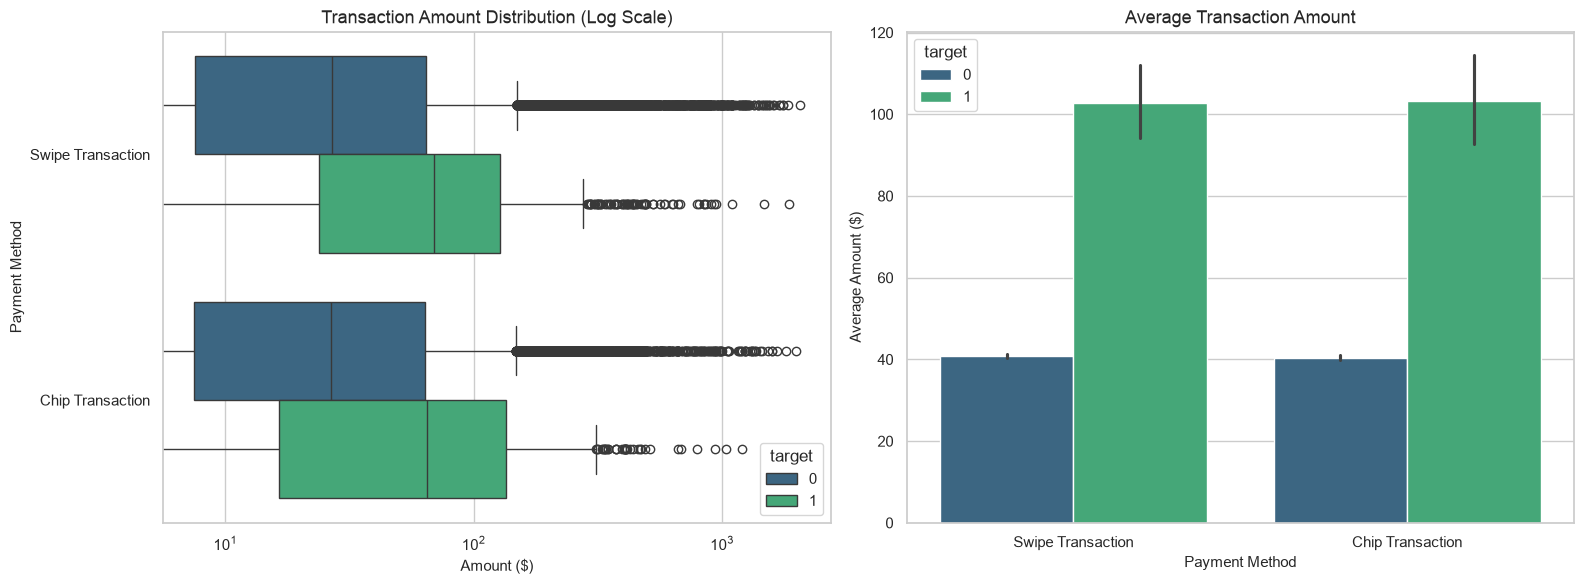

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.boxplot(data=df, x="amount", y="use_chip", hue="target", palette="viridis", ax=axes[0])
axes[0].set_xscale("log") 
axes[0].set_title("Transaction Amount Distribution (Log Scale)", fontsize=13)
axes[0].set_xlabel("Amount ($)", fontsize=11)
axes[0].set_ylabel("Payment Method", fontsize=11)

sns.barplot(data=df, x="use_chip", y="amount", hue="target", palette="viridis", ax=axes[1])
axes[1].set_title("Average Transaction Amount", fontsize=13)
axes[1].set_xlabel("Payment Method", fontsize=11)
axes[1].set_ylabel("Average Amount ($)", fontsize=11)

plt.tight_layout()
plt.show()

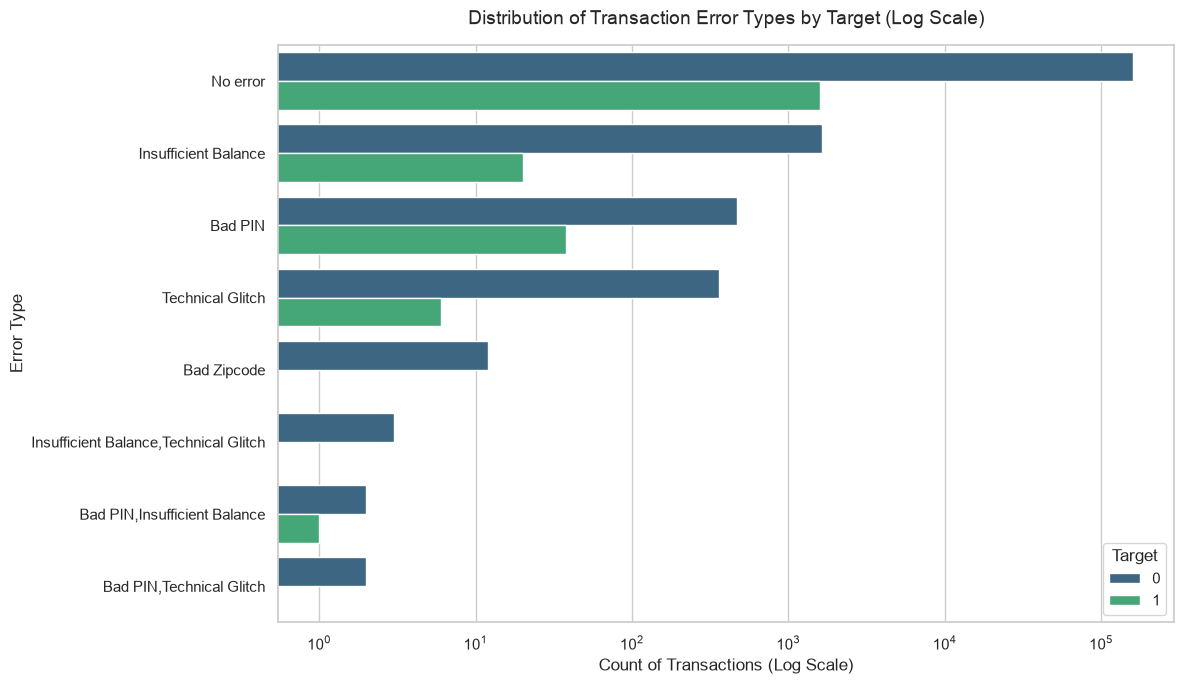

In [40]:
plt.figure(figsize=(12, 7))

plot_df = df.copy()
plot_df["errors"] = plot_df["errors"].fillna("No error")


errors_order = plot_df["errors"].value_counts().index

sns.countplot(data=plot_df, y="errors", hue="target", order=errors_order, palette="viridis")

plt.xscale("log")

plt.title("Distribution of Transaction Error Types by Target (Log Scale)", fontsize=14, pad=15)
plt.xlabel("Count of Transactions (Log Scale)", fontsize=12)
plt.ylabel("Error Type", fontsize=12)
plt.legend(title="Target", loc="lower right")
plt.tight_layout()
plt.show()

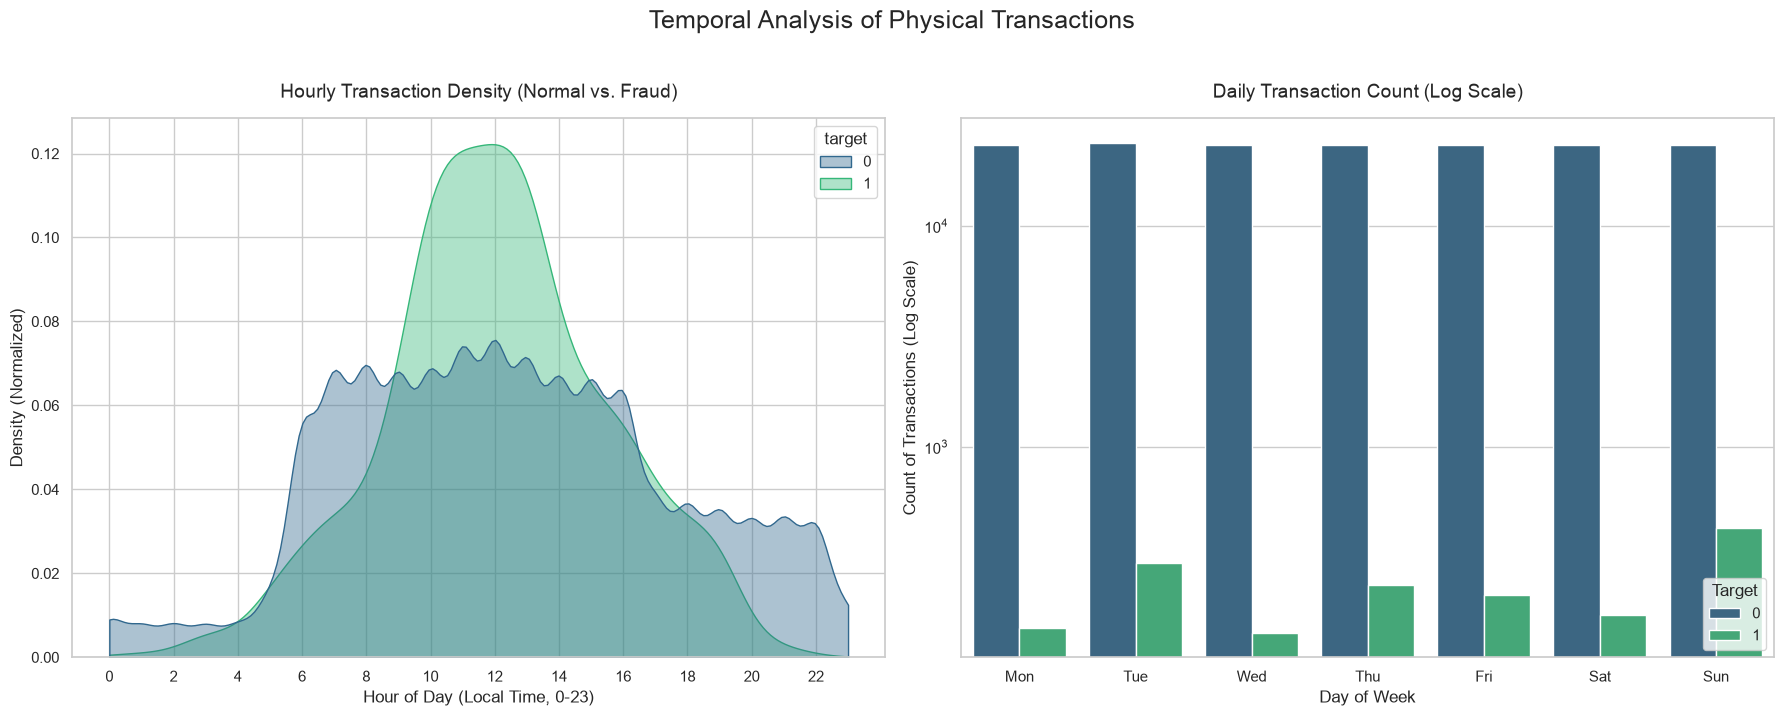

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

sns.kdeplot(data=df,x="hour",hue="target",fill=True,common_norm=False,  palette="viridis",alpha=0.4,clip=(0, 23), ax=axes[0])
axes[0].set_title("Hourly Transaction Density (Normal vs. Fraud)", fontsize=14, pad=15)
axes[0].set_xlabel("Hour of Day (Local Time, 0-23)", fontsize=12)
axes[0].set_ylabel("Density (Normalized)", fontsize=12)
axes[0].set_xticks(range(0, 24, 2)) 

plot_df = df.copy()
day_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
plot_df["day_name"] = plot_df["day_of_week"].map(day_map)

sns.countplot(data=plot_df,x="day_name",hue="target",order=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], palette="viridis",ax=axes[1])
axes[1].set_yscale("log")  

axes[1].set_title("Daily Transaction Count (Log Scale)", fontsize=14, pad=15)
axes[1].set_xlabel("Day of Week", fontsize=12)
axes[1].set_ylabel("Count of Transactions (Log Scale)", fontsize=12)
axes[1].legend(title="Target", loc="lower right")

plt.suptitle("Temporal Analysis of Physical Transactions", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_68884/2571086927.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


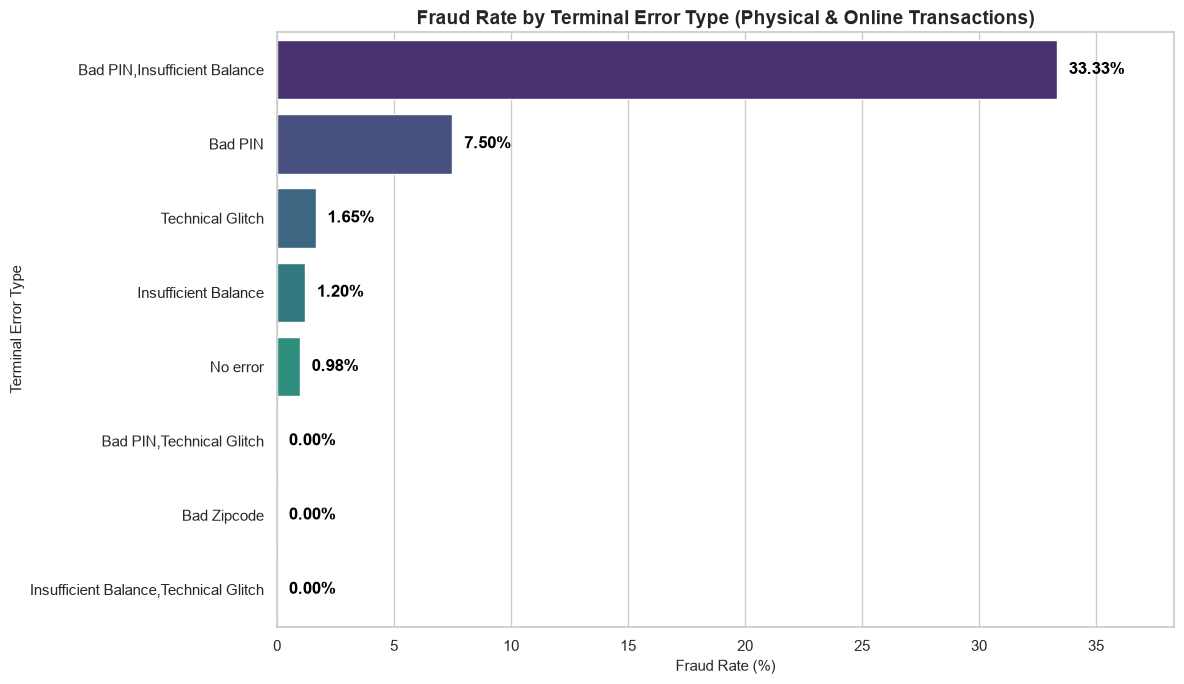

In [60]:

df_temp = df.copy()

df_temp["errors_clean"] = df_temp["errors"].fillna("No error")

if df_temp["target"].dtype == "object":
    df_temp["fraud_rate_pct"] = (df_temp["target"] == "Yes").astype(int) * 100
else:
    df_temp["fraud_rate_pct"] = df_temp["target"] * 100

order = df_temp.groupby("errors_clean")["fraud_rate_pct"].mean().sort_values(ascending=False).index

plt.figure(figsize=(12, 7))

sns.barplot(data=df_temp,x="fraud_rate_pct", y="errors_clean", order=order, palette="viridis",legend=False,errorbar=None)

plt.title("Fraud Rate by Terminal Error Type (Physical & Online Transactions)", fontsize=14, fontweight='bold')
plt.xlabel("Fraud Rate (%)", fontsize=11)
plt.ylabel("Terminal Error Type", fontsize=11)

means = df_temp.groupby("errors_clean")["fraud_rate_pct"].mean().loc[order]
for i, val in enumerate(means):
    plt.text(val + 0.5, i, f"{val:.2f}%", color='black', va='center', fontweight='bold')

plt.xlim(0, max(means) * 1.15 if max(means) > 0 else 100)

plt.tight_layout()
plt.show()

In [43]:

nomi = pgeocode.Nominatim('us')
clean_zips = pd.to_numeric(df["zip"], errors="coerce").fillna(0).astype(int).astype(str).str.zfill(5)


clean_zips = clean_zips.replace("00000", np.nan)
geo_df = nomi.query_postal_code(clean_zips.values)

df["transaction_latitude"] = geo_df["latitude"]
df["transaction_longitude"] = geo_df["longitude"]

In [44]:

def haversine_vectorized(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c 
    return km


In [45]:

df["distance_to_home_km"] = haversine_vectorized(df["longitude"], df["latitude"],df["transaction_longitude"], df["transaction_latitude"])
df["location_type"] = np.where(df["distance_to_home_km"] > 100, "Far (>100km)", "Close (<100km)")

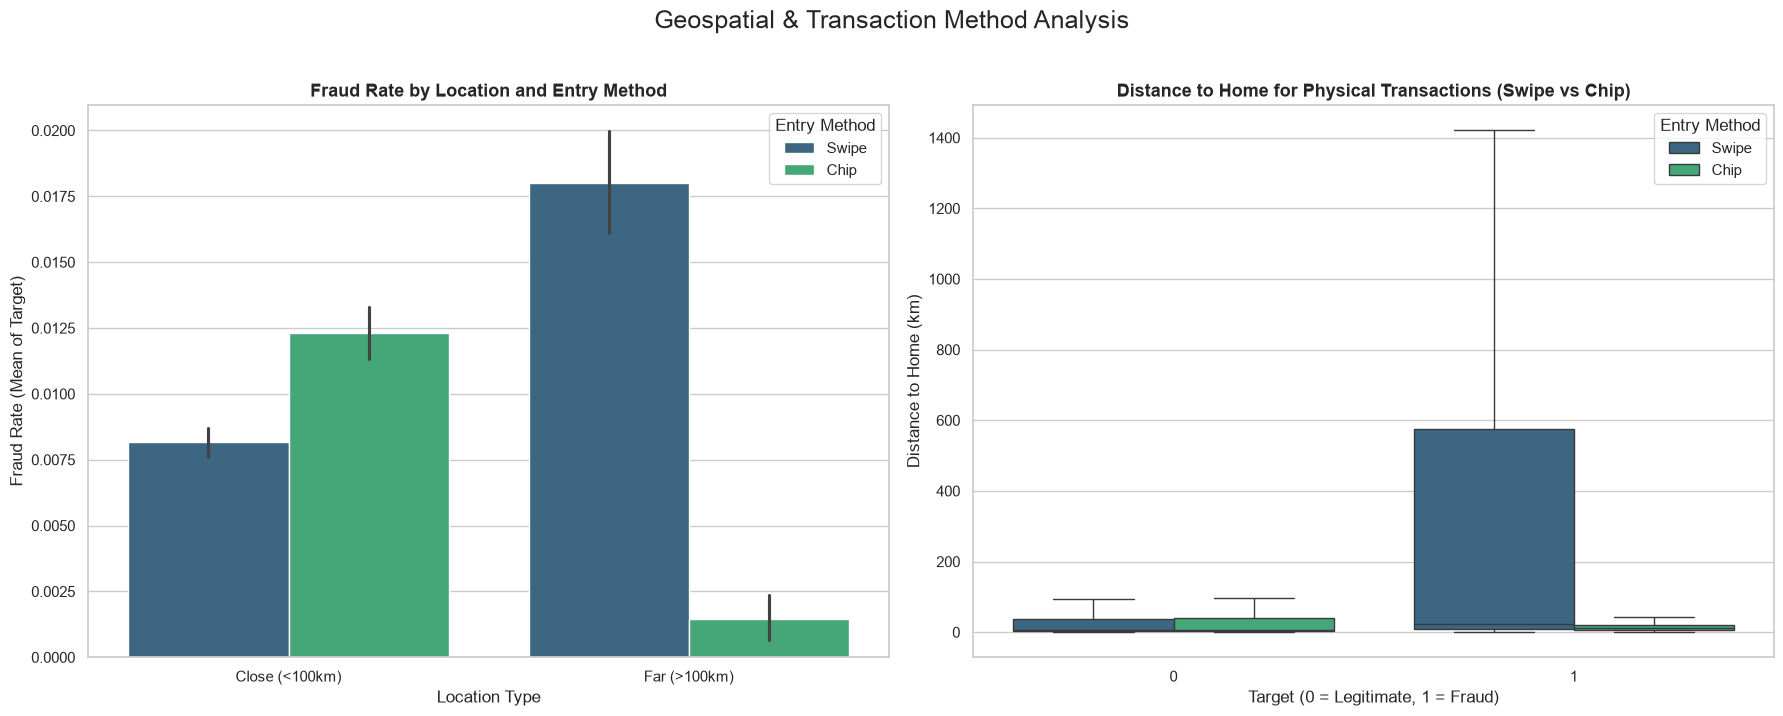

In [46]:

df["entry_method"] = df["use_chip"].astype(str).str.replace(" Transaction", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=df, x="location_type", y="target", hue="entry_method",palette="viridis", ax=axes[0])
axes[0].set_title("Fraud Rate by Location and Entry Method", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Location Type")
axes[0].set_ylabel("Fraud Rate (Mean of Target)")
axes[0].legend(title="Entry Method")


physical_df = df[df["entry_method"].isin(["Swipe", "Chip"])]

sns.boxplot(data=physical_df, x="target", y="distance_to_home_km", hue="entry_method", palette="viridis", showfliers=False,  ax=axes[1])
axes[1].set_title("Distance to Home for Physical Transactions (Swipe vs Chip)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Target (0 = Legitimate, 1 = Fraud)")
axes[1].set_ylabel("Distance to Home (km)")
axes[1].legend(title="Entry Method")

plt.suptitle("Geospatial & Transaction Method Analysis", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

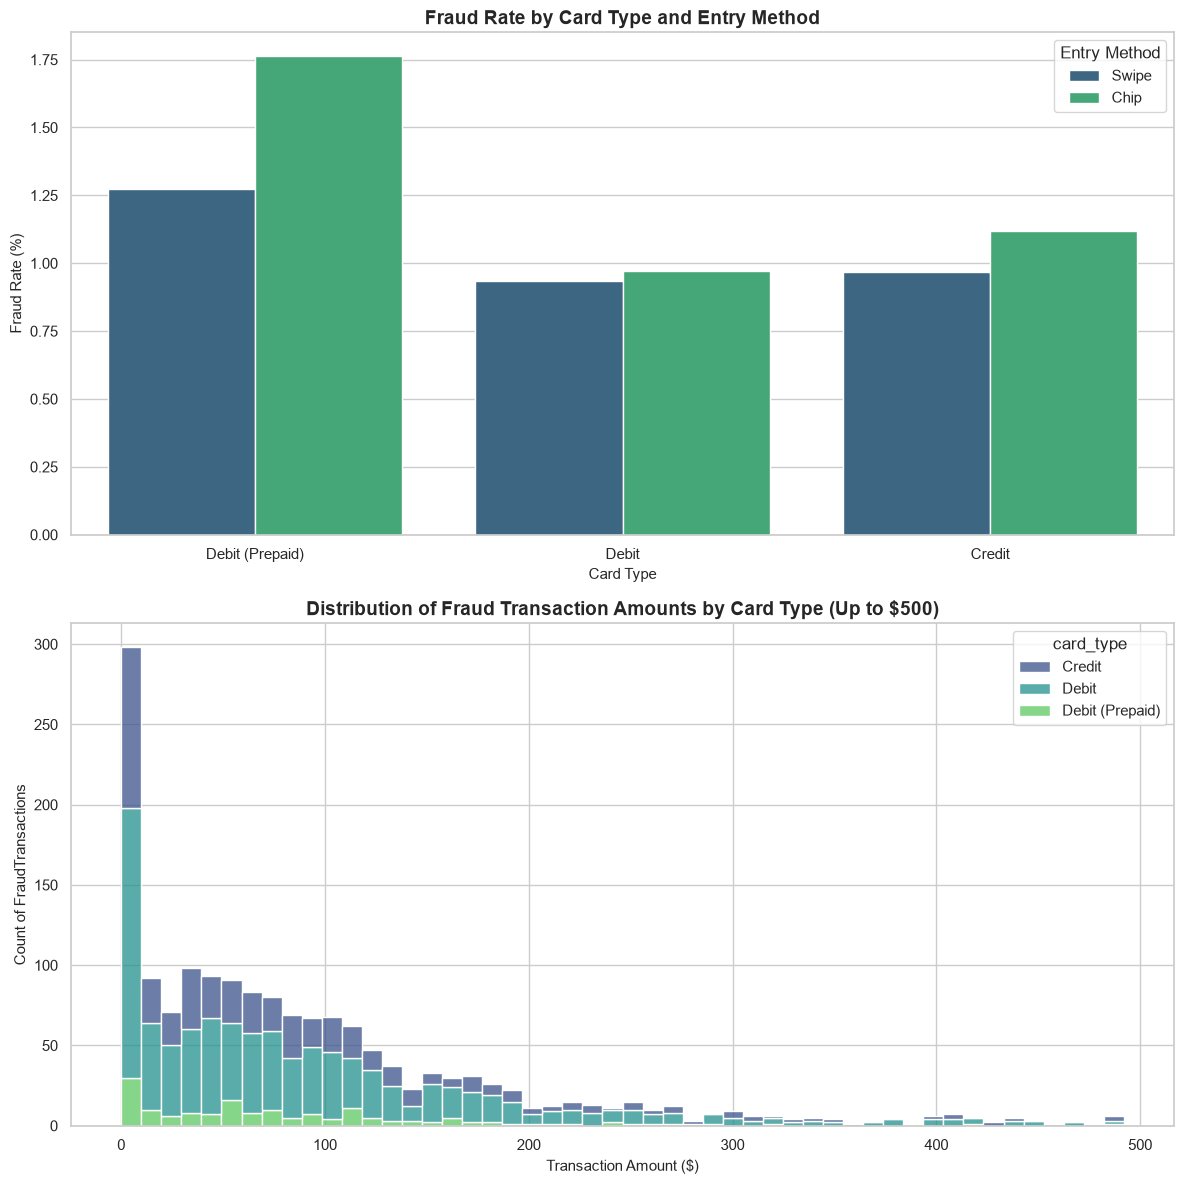

In [52]:


physical_df = df[df["entry_method"].isin(["Swipe", "Chip"])].copy()

if physical_df["target"].dtype == "object":
    physical_df["fraud_rate_pct"] = (physical_df["target"] == "Yes").astype(int) * 100
else:
    physical_df["fraud_rate_pct"] = physical_df["target"] * 100

if df["target"].dtype == "object":
    fraud_df = df[df["target"] == "Yes"].copy()
else:
    fraud_df = df[df["target"] == 1].copy()

fraud_df_filtered = fraud_df[fraud_df["amount"].between(0, 500)]

fig, axes = plt.subplots(2, 1, figsize=(12, 12))


sns.barplot(data=physical_df,x="card_type",              y="fraud_rate_pct",         hue="entry_method",       palette="viridis",errorbar=None,ax=axes[0])
axes[0].set_title("Fraud Rate by Card Type and Entry Method", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Card Type", fontsize=11)
axes[0].set_ylabel("Fraud Rate (%)", fontsize=11)
axes[0].legend(title="Entry Method")


sns.histplot(data=fraud_df_filtered,x="amount",hue="card_type",multiple="stack", palette="viridis",bins=50, ax=axes[1])
axes[1].set_title("Distribution of Fraud Transaction Amounts by Card Type (Up to $500)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Transaction Amount ($)", fontsize=11)
axes[1].set_ylabel("Count of FraudTransactions", fontsize=11)

plt.tight_layout()
plt.show()

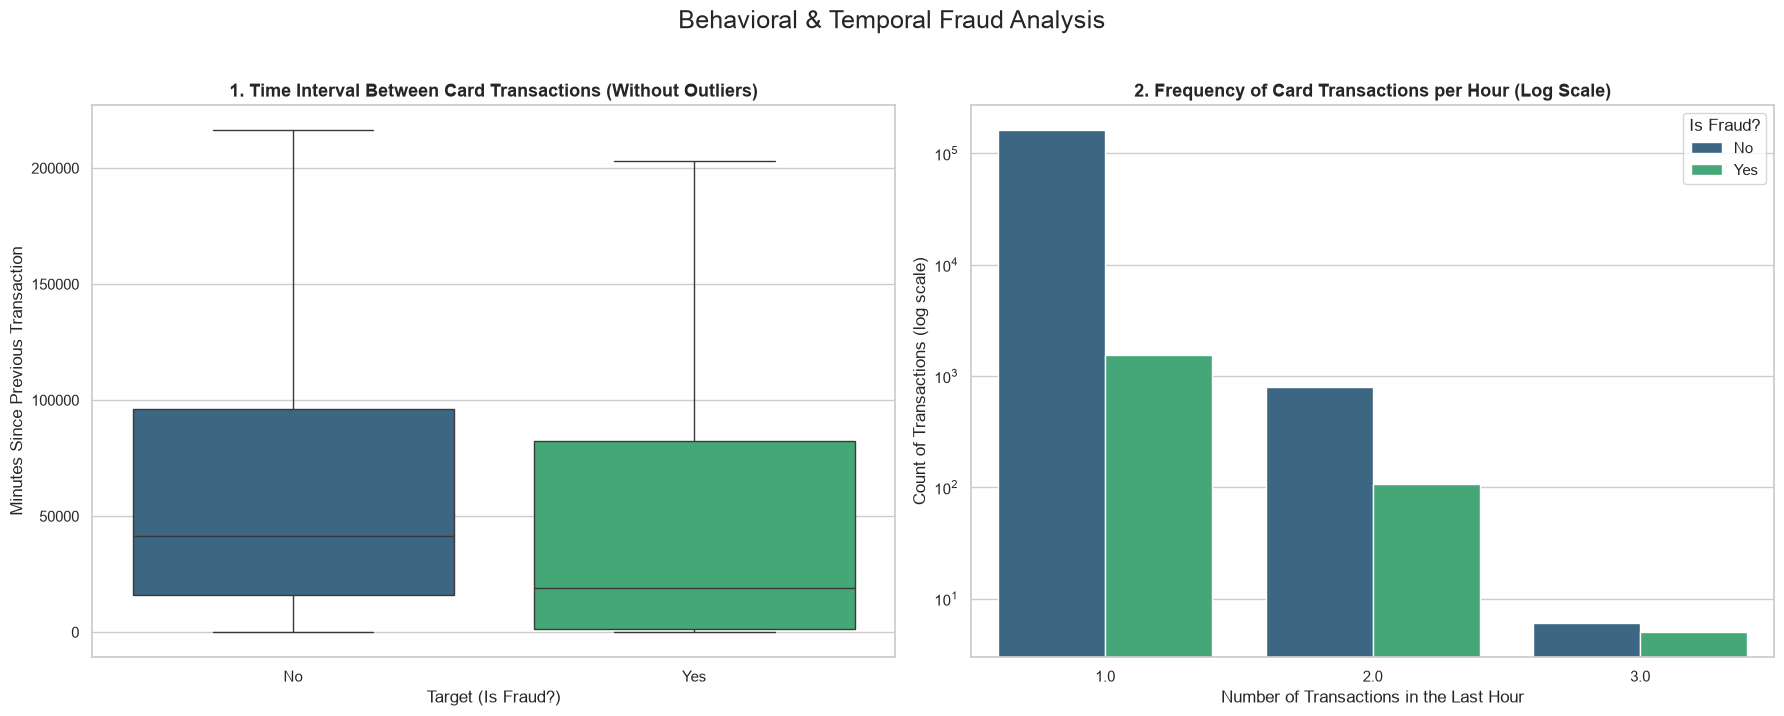

In [57]:


if df["target"].dtype != "object":
    df["target_text"] = df["target"].map({1: "Yes", 0: "No"})
else:
    df["target_text"] = df["target"]

df = df.sort_values(["card_id", "date"]).reset_index(drop=True)
df["date_dt"] = pd.to_datetime(df["date"])
df["time_diff_min"] = df.groupby("card_id")["date_dt"].diff().dt.total_seconds() / 60.0
df_temp = df.set_index("date_dt")
df["trx_count_1h"] = df_temp.groupby("card_id")["amount"].rolling("1h").count().values

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.boxplot(data=df, x="target_text", y="time_diff_min", palette="viridis", hue="target_text", legend=False, showfliers=False, ax=axes[0])
axes[0].set_title("1. Time Interval Between Card Transactions (Without Outliers)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Target (Is Fraud?)")
axes[0].set_ylabel("Minutes Since Previous Transaction")

sns.countplot(data=df, x="trx_count_1h", hue="target_text", palette="viridis", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("2. Frequency of Card Transactions per Hour (Log Scale)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Number of Transactions in the Last Hour")
axes[1].set_ylabel("Count of Transactions (log scale)")
axes[1].legend(title="Is Fraud?")

plt.suptitle("Behavioral & Temporal Fraud Analysis", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [61]:
df[df["target"]==1]


,date,id,client_id_x,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,hour,day_of_week,transaction_latitude,transaction_longitude,distance_to_home_km,location_type,entry_method,target_text,date_dt,time_diff_min
157,2015-06-29 12:24:00,16304149,556,2,51.31,Chip Transaction,11593,Munroe Falls,OH,44262.0,...,12,0,41.1420,-81.4376,20.006059,Close (<100km),Chip,Yes,2015-06-29 12:24:00,37326.0
543,2016-02-07 10:21:00,17346824,1156,12,110.97,Swipe Transaction,25525,Short Hills,NJ,7078.0,...,10,6,40.7368,-74.3271,0.431363,Close (<100km),Swipe,Yes,2016-02-07 10:21:00,575893.0
544,2016-02-07 10:49:00,17346992,1156,12,159.52,Swipe Transaction,48569,West Orange,NJ,7052.0,...,10,6,40.7859,-74.2568,7.998485,Close (<100km),Swipe,Yes,2016-02-07 10:49:00,28.0
562,2012-06-27 13:28:00,11318242,858,13,90.37,Swipe Transaction,29086,Harwood,TX,78632.0,...,13,2,29.6661,-97.4906,19.094627,Close (<100km),Swipe,Yes,2012-06-27 13:28:00,92229.0
563,2012-06-28 12:30:00,11322420,858,13,8.47,Swipe Transaction,78828,Yoakum,TX,77995.0,...,12,3,29.2840,-97.1306,38.386664,Close (<100km),Swipe,Yes,2012-06-28 12:30:00,1382.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164363,2014-03-30 10:29:00,14202873,452,6086,135.10,Swipe Transaction,28049,Strasburg,OH,44680.0,...,10,6,40.6003,-81.5366,1737.167900,Far (>100km),Swipe,Yes,2014-03-30 10:29:00,100821.0
164491,2014-01-04 11:33:00,13814739,1088,6095,25.69,Swipe Transaction,47155,Strasburg,OH,44680.0,...,11,5,40.6003,-81.5366,879.846699,Far (>100km),Swipe,Yes,2014-01-04 11:33:00,46407.0
164492,2014-01-05 09:54:00,13818910,1088,6095,257.41,Swipe Transaction,44971,Strasburg,OH,44680.0,...,9,6,40.6003,-81.5366,879.846699,Far (>100km),Swipe,Yes,2014-01-05 09:54:00,1341.0
164722,2016-05-29 10:28:00,17865061,1582,6110,155.00,Swipe Transaction,41361,Carmel,CA,93923.0,...,10,6,36.5457,-121.8949,11.638641,Close (<100km),Swipe,Yes,2016-05-29 10:28:00,32277.0


/var/folders/pk/2fr01p2d42j3b32375zb10ww0000gn/T/ipykernel_68884/2957948801.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(title="Is Fraud?")


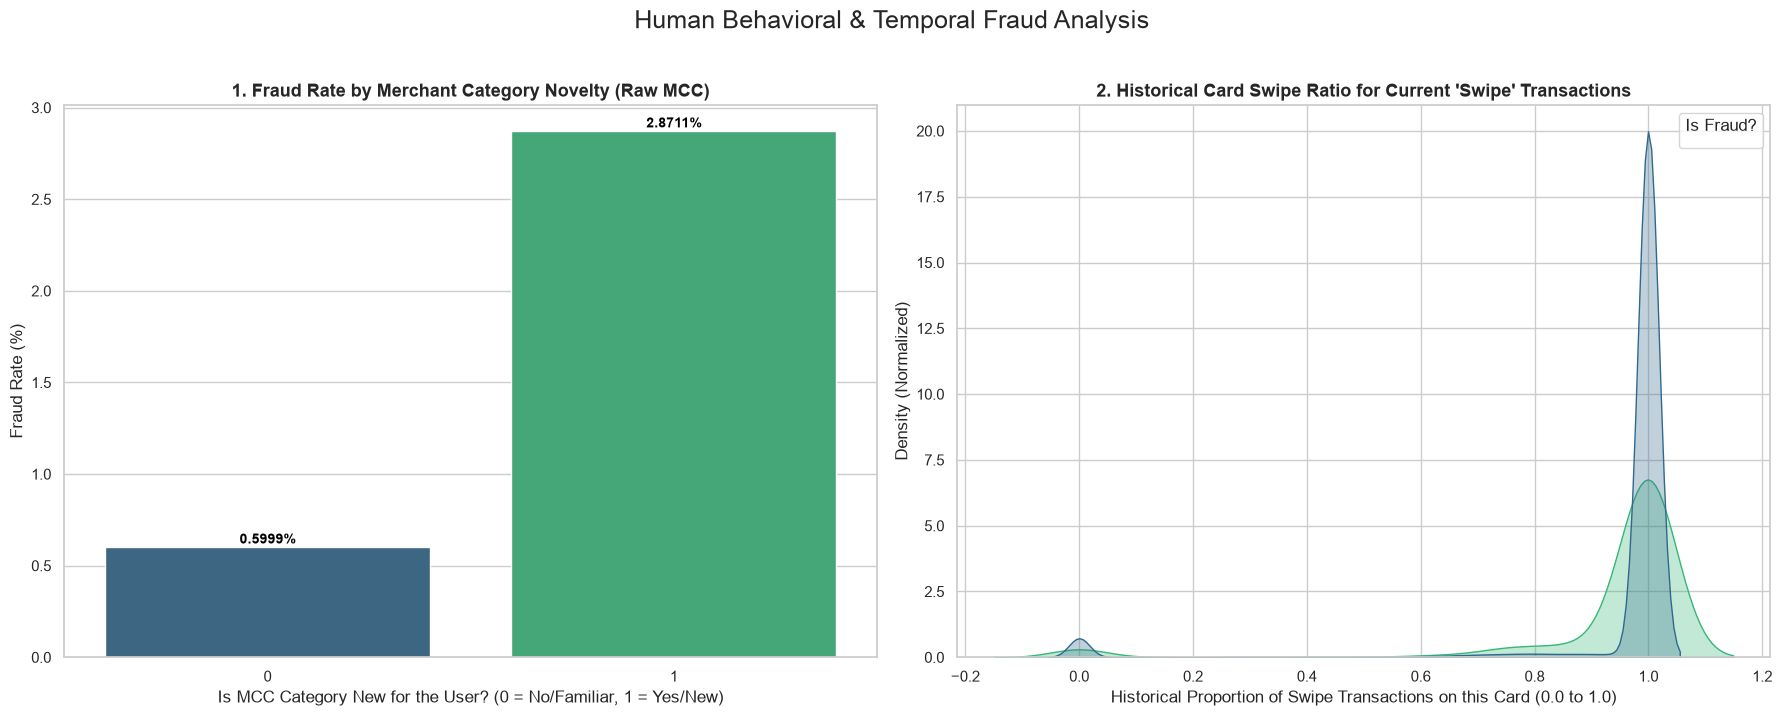

In [64]:


df_plot = df.copy()

if "entry_method" not in df_plot.columns:
    df_plot["entry_method"] = df_plot["use_chip"].astype(str).str.replace(" Transaction", "", regex=False)

df_plot = df_plot.sort_values(["card_id", "date"]).reset_index(drop=True)

user_col = "client_id_x"


df_plot["is_new_mcc"] = (~df_plot.duplicated(subset=[user_col, "mcc"])).astype(int)

is_swipe = (df_plot["entry_method"] == "Swipe").astype(int)
df_plot["card_swipe_ratio"] = (
    is_swipe.groupby(df_plot["card_id"])
    .transform(lambda x: x.shift(1).expanding().mean().fillna(0))
)

if df_plot["target"].dtype != "object":
    df_plot["target_text"] = df_plot["target"].map({1: "Yes", 0: "No"})
else:
    df_plot["target_text"] = df_plot["target"]

df_plot["target_pct"] = (df_plot["target_text"] == "Yes").astype(int) * 100


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=df_plot,
    x="is_new_mcc",
    y="target_pct",
    palette="viridis",
    hue="is_new_mcc",
    legend=False,
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("1. Fraud Rate by Merchant Category Novelty (Raw MCC)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Is MCC Category New for the User? (0 = No/Familiar, 1 = Yes/New)")
axes[0].set_ylabel("Fraud Rate (%)")

for p in axes[0].patches:
    height = p.get_height()
    if pd.notna(height) and height > 0:
        axes[0].annotate(f'{height:.4f}%', (p.get_x() + p.get_width() / 2., height + 0.005),
                    ha='center', va='bottom', fontsize=10, color='black', fontweight='bold')



swipe_now_df = df_plot[df_plot["entry_method"] == "Swipe"]

sns.kdeplot(
    data=swipe_now_df,
    x="card_swipe_ratio",
    hue="target_text",
    fill=True,
    alpha=0.3,
    palette="viridis",
    common_norm=False,
    ax=axes[1]
)
axes[1].set_title("2. Historical Card Swipe Ratio for Current 'Swipe' Transactions", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Historical Proportion of Swipe Transactions on this Card (0.0 to 1.0)")
axes[1].set_ylabel("Density (Normalized)")
axes[1].legend(title="Is Fraud?")

plt.suptitle("Human Behavioral & Temporal Fraud Analysis", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

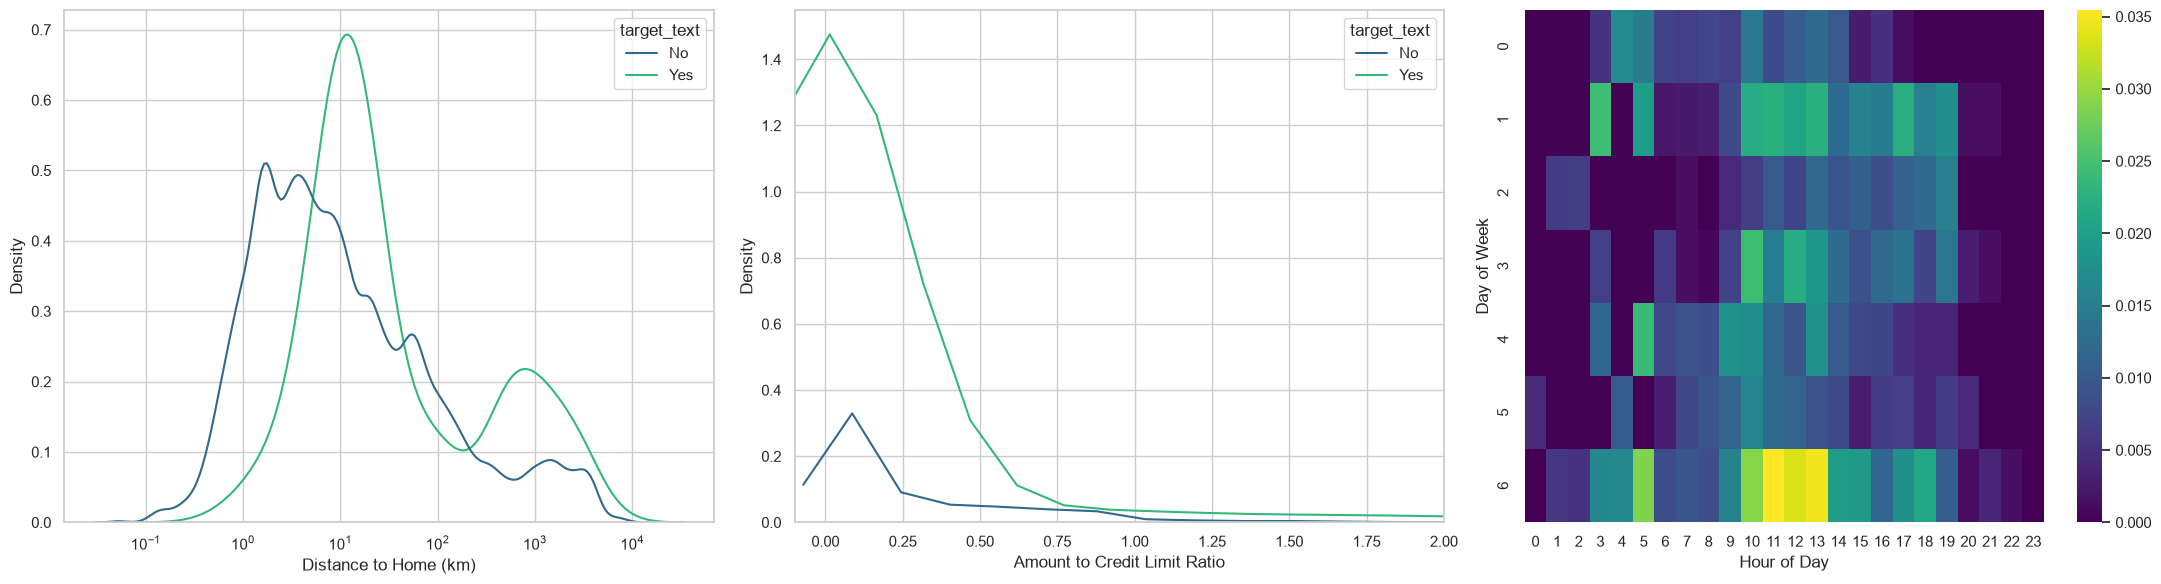

In [77]:

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.kdeplot(
    data=df,
    x="distance_to_home_km",
    hue="target_text",
    log_scale=True,
    common_norm=False,
    palette="viridis",
    ax=axes[0]
)
axes[0].set_xlabel("Distance to Home (km)")
axes[0].set_ylabel("Density")

df_util = df.copy()
df_util["amount"] = pd.to_numeric(df_util["amount"].astype(str).str.replace(r'[^\d.]', '', regex=True), errors="coerce")
df_util["credit_limit"] = pd.to_numeric(df_util["credit_limit"].astype(str).str.replace('$', '', regex=False), errors="coerce")
df_util["limit_utilization"] = df_util["amount"] / df_util["credit_limit"]

sns.kdeplot(
    data=df_util,
    x="limit_utilization",
    hue="target_text",
    common_norm=False,
    palette="viridis",
    ax=axes[1]
)
axes[1].set_xlim(-0.1, 2.0)
axes[1].set_xlabel("Amount to Credit Limit Ratio")
axes[1].set_ylabel("Density")

df_heat = df.copy()
df_heat["target_binary"] = (df_heat["target_text"].astype(str).str.lower().str.strip() == "yes").astype(int)
pivot_table = df_heat.pivot_table(
    index="day_of_week",
    columns="hour",
    values="target_binary",
    aggfunc="mean"
)

sns.heatmap(pivot_table, cmap="viridis", ax=axes[2])
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Day of Week")

plt.tight_layout()
plt.show()

In [84]:
fraud = df[df["target"]==1]

In [87]:
fraud.groupby(["use_chip"])["amount"].median()

use_chip
Chip Transaction     64.68
Swipe Transaction    69.05
Name: amount, dtype: float64

In [88]:
def pick_col(frame, name):
    for cand in (name, f'{name}_x', f'{name}_y'):
        if cand in frame.columns:
            return cand
    return None

fraud_physical = df[(df['target'] == 1) & (df['entry_method'].isin(['Swipe', 'Chip']))].copy()
print(fraud_physical['entry_method'].value_counts())

entry_method
Swipe    1098
Chip      551
Name: count, dtype: int64


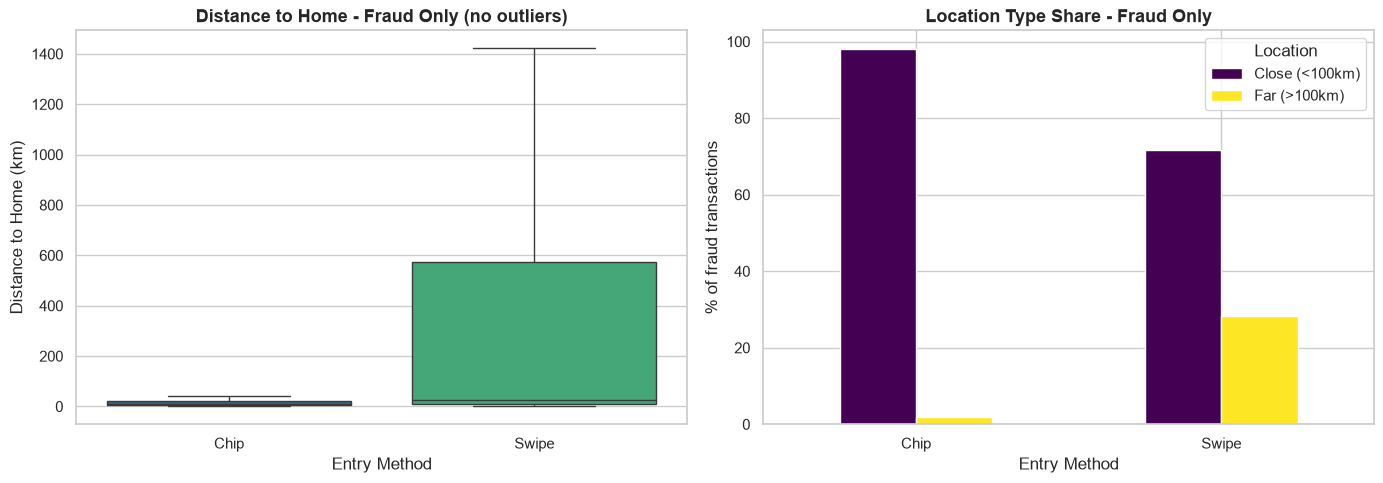

Swipe median/mean: 23.9 / 490.2 km
Chip  median/mean: 11.4 / 31.0 km
Mann-Whitney p = 2.6e-28


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=fraud_physical, x='entry_method', y='distance_to_home_km', hue='entry_method',
            palette='viridis', showfliers=False, legend=False, ax=axes[0])
axes[0].set_title('Distance to Home - Fraud Only (no outliers)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Entry Method')
axes[0].set_ylabel('Distance to Home (km)')

loc_ct = pd.crosstab(fraud_physical['entry_method'], fraud_physical['location_type'], normalize='index') * 100
loc_ct.plot(kind='bar', ax=axes[1], colormap='viridis')
axes[1].set_title('Location Type Share - Fraud Only', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% of fraud transactions')
axes[1].set_xlabel('Entry Method')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Location')

plt.tight_layout()
plt.show()

from scipy.stats import mannwhitneyu
sw = fraud_physical[fraud_physical['entry_method'] == 'Swipe']['distance_to_home_km'].dropna()
ch = fraud_physical[fraud_physical['entry_method'] == 'Chip']['distance_to_home_km'].dropna()
u, p = mannwhitneyu(sw, ch)
print(f'Swipe median/mean: {sw.median():.1f} / {sw.mean():.1f} km')
print(f'Chip  median/mean: {ch.median():.1f} / {ch.mean():.1f} km')
print(f'Mann-Whitney p = {p:.3g}')